In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Plot Two Time Series Together (5 Marks)

Given two series: temperature and humidity over 6 months,
- Plot them on the same figure with different y-axes
- Add a legend and axis labels

In [2]:
# Data reading and feature engineering
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Graded Assignment 2/DataSet_Question_1.csv')

df["date_cleaned"] = (df["date"].str.split("—").str[0].str.strip())
df["date_cleaned"] = pd.to_datetime(df["date_cleaned"],format="%A %d %B %Y, %H.%M")
df = df.sort_values(by='date_cleaned', ascending=False)
df.head()

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour,date_cleaned
487,"Monday 29 July 2024, 18.00 — 00.00",1.722276e+12,15.0,Broken clouds.,32.0,1001.0,75,2024-07-29,7,29,2024,0,18:00,00:00,2024-07-29 18:00:00
243,"Monday 29 July 2024, 18.00 — 00.00",1.722276e+12,15.0,Broken clouds.,32.0,1001.0,75,2024-07-29,7,29,2024,0,18:00,00:00,2024-07-29 18:00:00
426,"Monday 29 July 2024, 18.00 — 00.00",1.722276e+12,15.0,Broken clouds.,32.0,1001.0,75,2024-07-29,7,29,2024,0,18:00,00:00,2024-07-29 18:00:00
60,"Monday 29 July 2024, 18.00 — 00.00",1.722276e+12,15.0,Broken clouds.,32.0,1001.0,75,2024-07-29,7,29,2024,0,18:00,00:00,2024-07-29 18:00:00
365,"Monday 29 July 2024, 18.00 — 00.00",1.722276e+12,15.0,Broken clouds.,32.0,1001.0,75,2024-07-29,7,29,2024,0,18:00,00:00,2024-07-29 18:00:00


In [3]:
end_date = pd.Timestamp("2024-07-29 18:00:00")
start_date = end_date - pd.DateOffset(months=6)

print("start_date :", start_date)
print("end_date :", end_date)

df_six_months = df[(df["date_cleaned"] >= start_date) & (df["date_cleaned"] < end_date)]

start_date : 2024-01-29 18:00:00
end_date : 2024-07-29 18:00:00


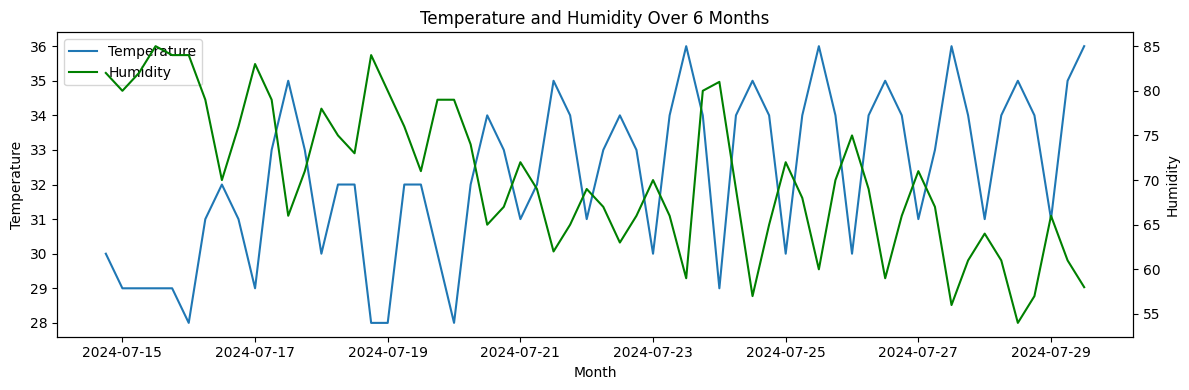

In [4]:
temperature = df_six_months['temp']
humidity = df_six_months['hum']
time = df_six_months['date_cleaned']

fig, ax = plt.subplots(figsize=(12, 4))

ax.set_xlabel("Month")
ax.set_ylabel("Temperature")
temp_line, = ax.plot(time, temperature, label="Temperature")
ax.tick_params(axis="y")

ax2 = ax.twinx()
ax2.set_ylabel("Humidity")
humidity_line, = ax2.plot(time, humidity, label="Humidity", color='g')
ax2.tick_params(axis="y")

lines = [temp_line, humidity_line]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc="best")


# 1a. Plot them on the same figure with different y-axes
# 1b. Add a legend and axis labels
# !IMPORTANT :  The code implementation considers recent 6 months data,
# but since csv contains only july data same is visible in the graph.

plt.title("Temperature and Humidity Over 6 Months")
plt.tight_layout()
plt.show()

### 2. Fit a Simple Linear Regression (5 Marks)

Write Python code to:
- Load a dataset containing hours_studied and exam_score
- Fit a simple linear regression model
- Print slope & intercept
- Plot data points and the regression line

Scikit Learn Linear Regression:
Slope: 9.783204555657944
Intercept: -0.499172987405764




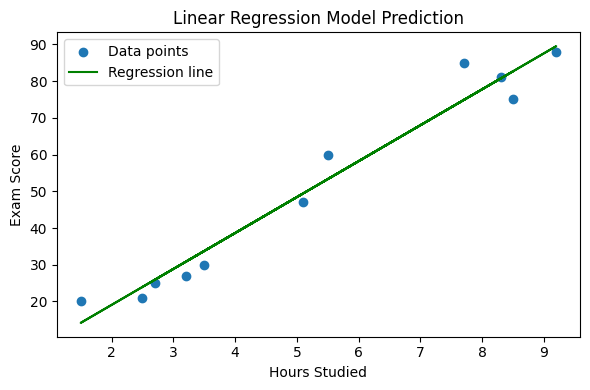

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 2a. Load a dataset containing hours_studied and exam_score
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Graded Assignment 2/Student_Scores.csv")

X = df[["Hours"]]
y = df["Scores"]

# 2b.Fit a simple linear regression model
model = LinearRegression()
model.fit(X, y)

# 2c. Print slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print("Scikit Learn Linear Regression:")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}\n\n")

# 2d. Plot data points and the regression line
y_pred = model.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X, y, label="Data points")
plt.plot(X, y_pred, label="Regression line", color='g')

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression Model Prediction")
plt.legend()
plt.tight_layout()
plt.show()


### 3. Gradient Descent Implementation (5 Marks)
Without using libraries:

- Implement linear regression using batch gradient descent

- Plot cost/error vs iterations

Compare learned slope/intercept with scikit-learn’s model.

Gradient Descent IMplementation:
Slope : 9.777557261294199
Intercept : -0.4622325448203228



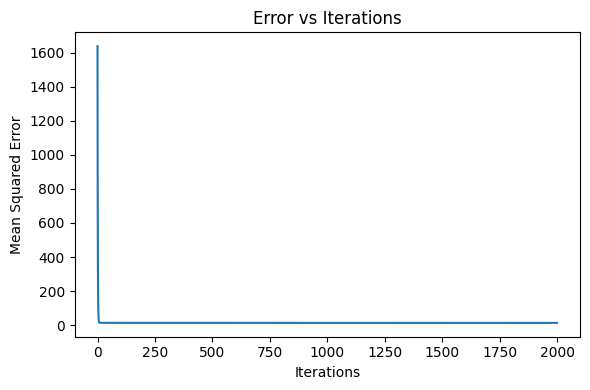

In [6]:
# 3a. Implement linear regression using batch gradient descent

X = df["Hours"].values
y_gt = df["Scores"].values
m = len(X)
X = X.reshape(-1, 1)

w = 0.0
b = 0.0

lr = 0.01
iters = 2000

error_over_iterations = []
for i in range(iters):
    y_pred = w * X.flatten() + b

    error = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    error_over_iterations.append(error)

    dw = (1 / m) * np.sum((y_pred - y_gt) * X.flatten())
    db = (1 / m) * np.sum(y_pred - y_gt)

    w = w - lr * dw
    b = b - lr * db

print("Gradient Descent IMplementation:")
print(f"Slope : {w}")
print(f"Intercept : {b}\n")

# 3b. Plot cost/error vs iterations
plt.figure(figsize=(6, 4))
plt.plot(range(iters), error_over_iterations)
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.title("Error vs Iterations")
plt.tight_layout()
plt.show()

3c. Compare learned slope/intercept with scikit-learn's model.


Scikit Learn Linear Regression:

> Slope: 9.783204555657944

>Intercept: -0.499172987405764


Gradient Descent Implementation:

>Slope : 9.777557261294199

>Intercept : -0.4622325448203228


From above values we can understand that the weight and bias values achieved through the library implementation and custom implementation are nearly same.